# Superstore Sales – Exploratory Data Analysis

Quick look at sales, profit, discounts, and customer behaviour using the Sample Superstore dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 10

BLUE  = '#2C7BB6'
GREEN = '#1A9641'
RED   = '#D7191C'

## 1. Load the Data

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print('Shape:', df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 2. Cleaning

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

df['Year']      = df['Order Date'].dt.year
df['Month']     = df['Order Date'].dt.month
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print('Ship Days stats:')
print(df['Ship Days'].describe().round(2))
print('\nNegative shipping days:', (df['Ship Days'] < 0).sum())

Ship Days stats:
count    9994.00
mean        3.96
std         1.75
min         0.00
25%         3.00
50%         4.00
75%         5.00
max         7.00
Name: Ship Days, dtype: float64

Negative shipping days: 0


## 3. General Statistics

In [6]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [7]:
total_sales     = df['Sales'].sum()
total_profit    = df['Profit'].sum()
unique_orders   = df['Order ID'].nunique()
unique_customers = df['Customer ID'].nunique()
profit_margin   = (total_profit / total_sales) * 100

print(f'Total Sales:        ${total_sales:,.2f}')
print(f'Total Profit:       ${total_profit:,.2f}')
print(f'Profit Margin:      {profit_margin:.2f}%')
print(f'Unique Orders:      {unique_orders}')
print(f'Unique Customers:   {unique_customers}')

Total Sales:        $2,297,200.86
Total Profit:       $286,397.02
Profit Margin:      12.47%
Unique Orders:      5009
Unique Customers:   793


## 4. Sales by Category

In [8]:
cat_summary = df.groupby('Category').agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Num_Orders   = ('Order ID', 'count')
).reset_index()

cat_summary['Profit_Margin'] = (
    cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100
).round(2)

cat_summary.sort_values('Total_Sales', ascending=False)

,Category,Total_Sales,Total_Profit,Num_Orders,Profit_Margin
2,Technology,836154.0330,145454.9481,1847,17.40
0,Furniture,741999.7953,18451.2728,2121,2.49
1,Office Supplies,719047.0320,122490.8008,6026,17.04


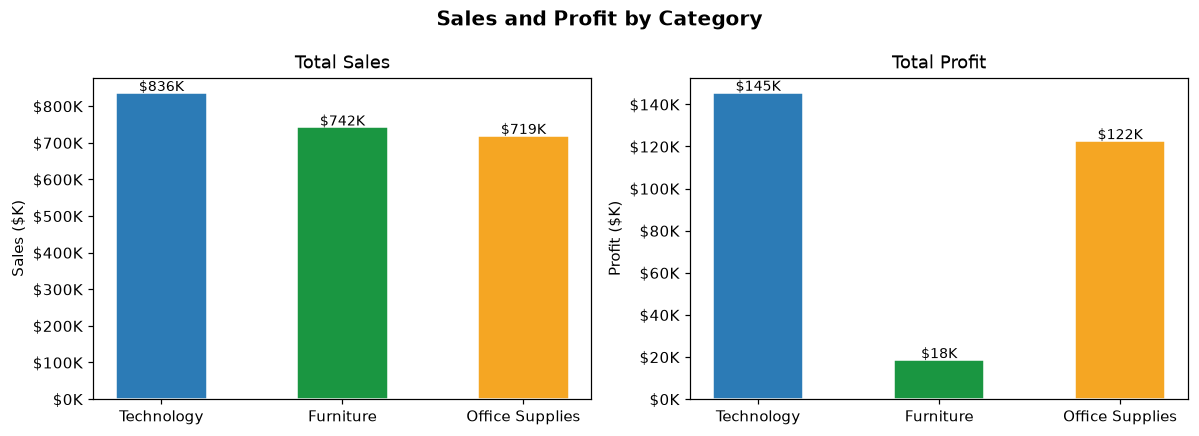

In [9]:
cat_s  = cat_summary.sort_values('Total_Sales', ascending=False)
colors = [BLUE, GREEN, '#F5A623']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Sales and Profit by Category', fontsize=13, fontweight='bold')

axes[0].bar(cat_s['Category'], cat_s['Total_Sales'] / 1e3,
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Total Sales')
axes[0].set_ylabel('Sales ($K)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
for b in axes[0].patches:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 f'${b.get_height():.0f}K', ha='center', fontsize=9)

axes[1].bar(cat_s['Category'], cat_s['Total_Profit'] / 1e3,
            color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Total Profit')
axes[1].set_ylabel('Profit ($K)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
for b in axes[1].patches:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 f'${b.get_height():.0f}K', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig1_category.png', bbox_inches='tight')
plt.show()

## 5. Sub-Category Breakdown

In [10]:
sub_summary = df.groupby('Sub-Category').agg(
    Total_Sales  = ('Sales',  'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

sub_summary['Profit_Margin'] = (
    sub_summary['Total_Profit'] / sub_summary['Total_Sales'] * 100
).round(2)

print('Top 5 by Sales:')
print(sub_summary.sort_values('Total_Sales', ascending=False).head(5).to_string(index=False))
print()
print('Bottom 5 by Profit:')
print(sub_summary.sort_values('Total_Profit').head(5).to_string(index=False))

Top 5 by Sales:
Sub-Category  Total_Sales  Total_Profit  Profit_Margin
      Phones   330007.054    44515.7306          13.49
      Chairs   328449.103    26590.1663           8.10
     Storage   223843.608    21278.8264           9.51
      Tables   206965.532   -17725.4811          -8.56
     Binders   203412.733    30221.7633          14.86

Bottom 5 by Profit:
Sub-Category  Total_Sales  Total_Profit  Profit_Margin
      Tables  206965.5320   -17725.4811          -8.56
   Bookcases  114879.9963    -3472.5560          -3.02
    Supplies   46673.5380    -1189.0995          -2.55
   Fasteners    3024.2800      949.5182          31.40
    Machines  189238.6310     3384.7569           1.79


In [11]:
losing = sub_summary[sub_summary['Total_Profit'] < 0]
print('Sub-categories with losses:', losing['Sub-Category'].tolist())

Sub-categories with losses: ['Bookcases', 'Supplies', 'Tables']


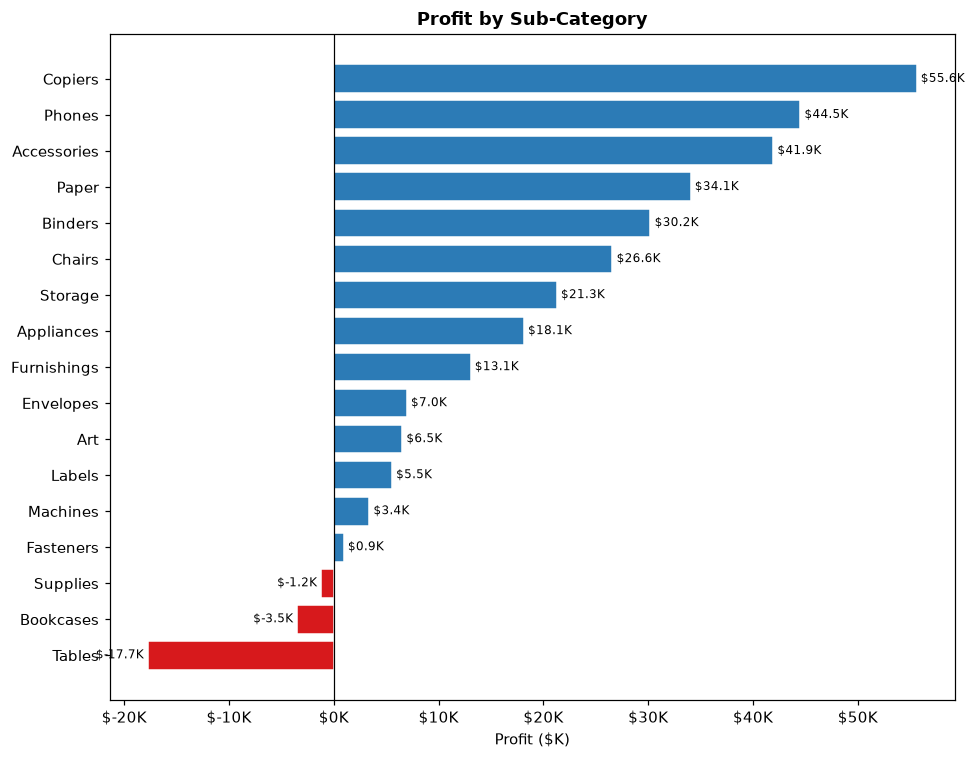

In [12]:
sub_plot   = sub_summary.sort_values('Total_Profit')
bar_colors = [RED if v < 0 else BLUE for v in sub_plot['Total_Profit']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(sub_plot['Sub-Category'], sub_plot['Total_Profit'] / 1e3,
        color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Profit ($K)')
ax.set_title('Profit by Sub-Category', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
for b in ax.patches:
    w = b.get_width()
    ax.text(w + (0.4 if w >= 0 else -0.4),
            b.get_y() + b.get_height()/2,
            f'${w:.1f}K', va='center',
            ha='left' if w >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('fig2_subcategory_profit.png', bbox_inches='tight')
plt.show()

## 6. Yearly Trend

In [13]:
yearly = df.groupby('Year').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).reset_index()

yearly['Sales_Growth_pct'] = yearly['Sales'].pct_change() * 100
yearly.round(2)

,Year,Sales,Profit,Sales_Growth_pct
0,2014,484247.50,49543.97,NaN
1,2015,470532.51,61618.60,-2.83
2,2016,609205.60,81795.17,29.47
3,2017,733215.26,93439.27,20.36


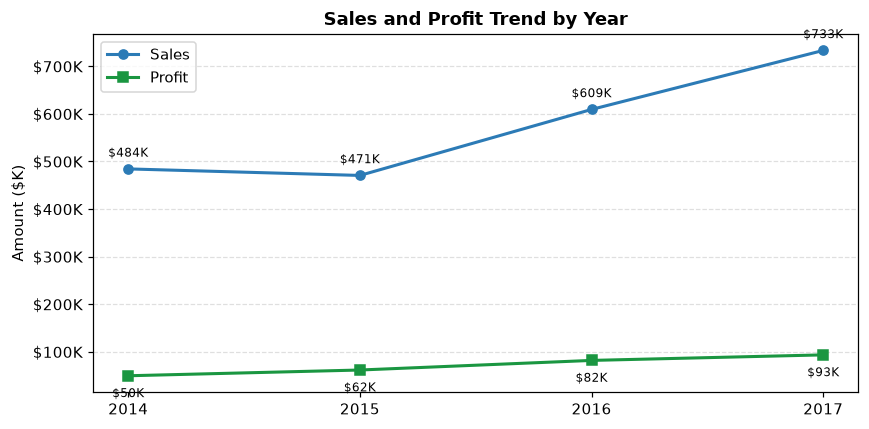

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yearly['Year'], yearly['Sales']  / 1e3,
        marker='o', color=BLUE,  linewidth=2, label='Sales')
ax.plot(yearly['Year'], yearly['Profit'] / 1e3,
        marker='s', color=GREEN, linewidth=2, label='Profit')

for _, row in yearly.iterrows():
    ax.annotate(f'${row["Sales"]/1e3:.0f}K',
                (row['Year'], row['Sales']/1e3),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
    ax.annotate(f'${row["Profit"]/1e3:.0f}K',
                (row['Year'], row['Profit']/1e3),
                textcoords='offset points', xytext=(0, -14), ha='center', fontsize=8)

ax.set_title('Sales and Profit Trend by Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount ($K)')
ax.set_xticks(yearly['Year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig3_yearly_trend.png', bbox_inches='tight')
plt.show()

## 7. Regional Performance

In [15]:
region_summary = df.groupby('Region').agg(
    Total_Sales   = ('Sales',       'sum'),
    Total_Profit  = ('Profit',      'sum'),
    Num_Customers = ('Customer ID', 'nunique')
).reset_index()

region_summary['Profit_Margin'] = (
    region_summary['Total_Profit'] / region_summary['Total_Sales'] * 100
).round(2)

region_summary.sort_values('Total_Sales', ascending=False)

,Region,Total_Sales,Total_Profit,Num_Customers,Profit_Margin
3,West,725457.8245,108418.4489,686,14.94
1,East,678781.2400,91522.7800,674,13.48
0,Central,501239.8908,39706.3625,629,7.92
2,South,391721.9050,46749.4303,512,11.93


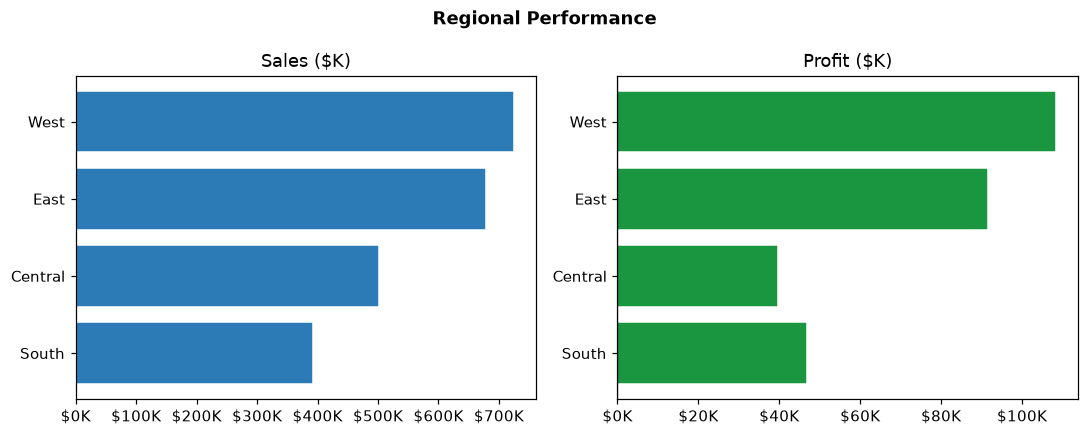

In [16]:
region_s = region_summary.sort_values('Total_Sales')
p_colors = [GREEN if v > 0 else RED for v in region_s['Total_Profit']]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Regional Performance', fontsize=12, fontweight='bold')

axes[0].barh(region_s['Region'], region_s['Total_Sales'] / 1e3,
             color=BLUE, edgecolor='white')
axes[0].set_title('Sales ($K)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

axes[1].barh(region_s['Region'], region_s['Total_Profit'] / 1e3,
             color=p_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit ($K)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('fig5_region.png', bbox_inches='tight')
plt.show()

In [17]:
state_profit = df.groupby('State')['Profit'].sum().sort_values()
print('5 worst states by profit:')
print(state_profit.head(5))

5 worst states by profit:
State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Name: Profit, dtype: float64


## 8. Discount Impact on Profit

In [18]:
bins   = [-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0]
labels = ['No Discount', '0-10%', '10-20%', '20-30%', '30-50%', '50%+']
df['Discount_Group'] = pd.cut(df['Discount'], bins=bins, labels=labels)

disc_effect = df.groupby('Discount_Group', observed=True).agg(
    Avg_Profit = ('Profit', 'mean'),
    Num_Orders = ('Order ID', 'count')
).reset_index()

disc_effect.round(2)

,Discount_Group,Avg_Profit,Num_Orders
0,No Discount,66.90,4798
1,0-10%,96.06,94
2,10-20%,24.74,3709
3,20-30%,-45.68,227
4,30-50%,-156.28,310
5,50%+,-89.44,856


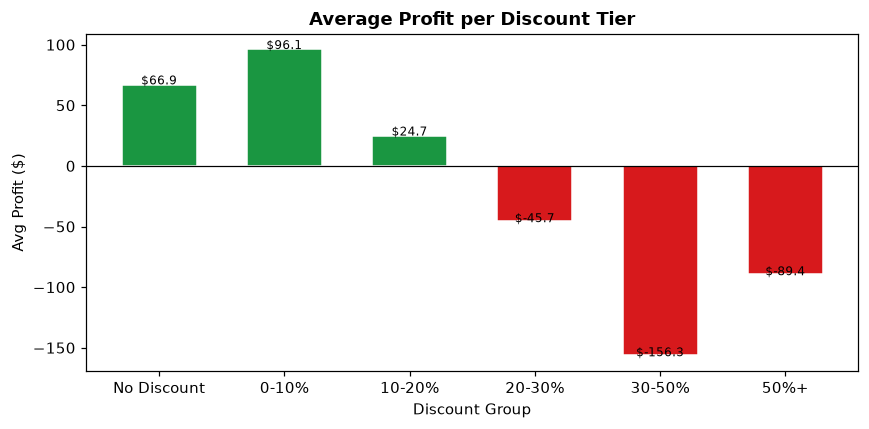

In [19]:
d_colors = [GREEN if v > 0 else RED for v in disc_effect['Avg_Profit']]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(disc_effect['Discount_Group'].astype(str),
       disc_effect['Avg_Profit'], color=d_colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit per Discount Tier', fontsize=12, fontweight='bold')
ax.set_xlabel('Discount Group')
ax.set_ylabel('Avg Profit ($)')
for b in ax.patches:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2,
            h + (0.3 if h >= 0 else -0.8),
            f'${h:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig4_discount_profit.png', bbox_inches='tight')
plt.show()

## 9. Customer Segments

In [20]:
seg_summary = df.groupby('Segment').agg(
    Total_Sales   = ('Sales',       'sum'),
    Total_Profit  = ('Profit',      'sum'),
    Num_Customers = ('Customer ID', 'nunique')
).reset_index()

seg_summary['Avg_Sales_Per_Customer'] = (
    seg_summary['Total_Sales'] / seg_summary['Num_Customers']
).round(2)

seg_summary

,Segment,Total_Sales,Total_Profit,Num_Customers,Avg_Sales_Per_Customer
0,Consumer,1.161401e+06,134119.2092,409,2839.61
1,Corporate,7.061464e+05,91979.1340,236,2992.15
2,Home Office,4.296531e+05,60298.6785,148,2903.06


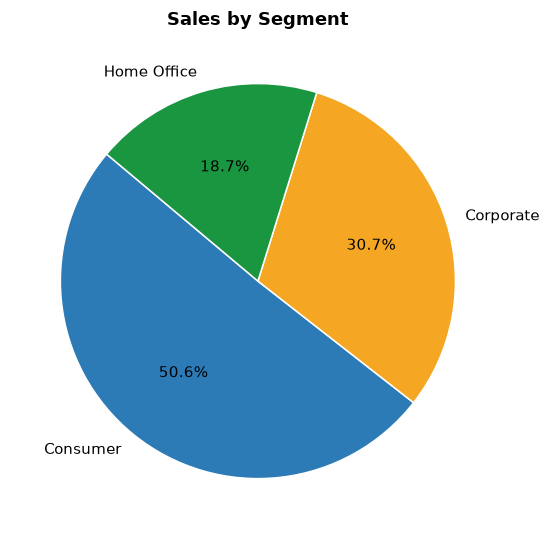

In [21]:
seg_pie = df.groupby('Segment')['Sales'].sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(seg_pie, labels=seg_pie.index, autopct='%1.1f%%',
       colors=[BLUE, '#F5A623', GREEN],
       startangle=140, wedgeprops={'edgecolor': 'white'})
ax.set_title('Sales by Segment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_segment_pie.png', bbox_inches='tight')
plt.show()

## 10. Shipping Mode

In [22]:
ship_summary = df.groupby('Ship Mode').agg(
    Avg_Ship_Days = ('Ship Days', 'mean'),
    Total_Orders  = ('Order ID',  'count'),
    Total_Sales   = ('Sales',     'sum')
).reset_index()

ship_summary['Avg_Ship_Days'] = ship_summary['Avg_Ship_Days'].round(1)
ship_summary

,Ship Mode,Avg_Ship_Days,Total_Orders,Total_Sales
0,First Class,2.2,1538,3.514284e+05
1,Same Day,0.0,543,1.283631e+05
2,Second Class,3.2,1945,4.591936e+05
3,Standard Class,5.0,5968,1.358216e+06


## 11. Top Customers

In [23]:
top_customers = df.groupby('Customer Name').agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Num_Orders   = ('Order ID', 'nunique')
).reset_index().sort_values('Total_Sales', ascending=False)

top_customers.head(10).reset_index(drop=True)

,Customer Name,Total_Sales,Total_Profit,Num_Orders
0,Sean Miller,25043.050,-1980.7393,5
1,Tamara Chand,19052.218,8981.3239,5
2,Raymond Buch,15117.339,6976.0959,6
3,Tom Ashbrook,14595.620,4703.7883,4
4,Adrian Barton,14473.571,5444.8055,10
5,Ken Lonsdale,14175.229,806.8550,12
6,Sanjit Chand,14142.334,5757.4119,9
7,Hunter Lopez,12873.298,5622.4292,6
8,Sanjit Engle,12209.438,2650.6769,11
9,Christopher Conant,12129.072,2177.0493,5


## 12. Key Findings

In [24]:
top_cat      = cat_summary.sort_values('Total_Sales', ascending=False).iloc[0]
low_margin   = cat_summary.sort_values('Profit_Margin').iloc[0]
losing_subs  = sub_summary[sub_summary['Total_Profit'] < 0]['Sub-Category'].tolist()
best_region  = region_summary.sort_values('Total_Profit', ascending=False).iloc[0]
worst_region = region_summary.sort_values('Total_Profit').iloc[0]
top_cust     = top_customers.iloc[0]
best_year    = yearly.sort_values('Sales', ascending=False).iloc[0]['Year']

print(f'1. Best-selling category   : {top_cat["Category"]} (${top_cat["Total_Sales"]:,.0f})')
print(f'2. Lowest margin category  : {low_margin["Category"]} ({low_margin["Profit_Margin"]}%)')
print(f'3. Loss-making sub-cats    : {losing_subs}')
print(f'4. Most profitable region  : {best_region["Region"]}')
print(f'5. Least profitable region : {worst_region["Region"]}')
print(f'6. Top customer            : {top_cust["Customer Name"]} (${top_cust["Total_Sales"]:,.0f})')
print(f'7. Peak sales year         : {best_year}')
print('8. Heavy discounts (30%+) consistently lead to losses')

1. Best-selling category   : Technology ($836,154)
2. Lowest margin category  : Furniture (2.49%)
3. Loss-making sub-cats    : ['Bookcases', 'Supplies', 'Tables']
4. Most profitable region  : West
5. Least profitable region : Central
6. Top customer            : Sean Miller ($25,043)
7. Peak sales year         : 2017.0
8. Heavy discounts (30%+) consistently lead to losses
